<a href="https://colab.research.google.com/github/OlhaZahrebelna/python_for_ds_task/blob/main/ZahrebelnaOlha_%22Computer_Vision_with_PyTorch_Excercises%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому наборі завдань закріпимо те, що було на лекції з Computer Vision.

# Computer Vision with PyTorch Excercises


## 1. Наведіть 3 галузі промисловості, де комп'ютерний зір використовується сьогодні (можна згадати з лекції, або провести міні-рісерч).

Контроль якості та дефектоскопія

Сортування та пакування

Роботизована навігація (дрони, навігатори)

Автомобільна індустрія


## 2. Виділіть 20 хвилин аби ознайомитись та переглянути сайт [CNN Explainer](https://poloclub.github.io/cnn-explainer/).

* Завантажте власне будь-яке зображення за допомогою кнопки Upload" на сайті та подивіться, що відбувається на кожному шарі CNN, коли ваше зображення проходить через нього.

Напишіть 3 пункти, що ви дізнались після цієї вправи?

Зрозуміла як працюює:
 Convolution(згортка),
 ReLU.
Також зрозуміла навішо розділяється на червоний, зелений та синій



## 3. Завантажте навчальні та тестові набори даних [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST).

MNIST - базовий набір даних для задач Computer Vision. Часто використовується для навчання.

- Виведіть, скільки елементів в кожному наборі.
- Покажіть формат (розмірності) кожної картинки.
- Виведіть, які класи представлені в цьому наборі даних.

In [1]:
# Базові бібліотеки
import time
from timeit import default_timer as timer

# Відображення прогресу
from tqdm.auto import tqdm

# PyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader

# Torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Візуалізація
import matplotlib.pyplot as plt

# Додаткові функції
from helper_functions import accuracy_fn, print_train_time

# Перевірка та встановлення необхідних пакетів
try:
    import torchmetrics
    import mlxtend

    print(f"torchmetrics версія: {torchmetrics.__version__}")
    print(f"mlxtend версія: {mlxtend.__version__}")

    assert int(mlxtend.__version__.split(".")[1]) >= 19, \
        "Версія mlxtend повинна бути 0.19.0 або новіша"

except ImportError:
    !pip install -q torchmetrics mlxtend

    import torchmetrics
    import mlxtend

    print(f"torchmetrics версія: {torchmetrics.__version__}")
    print(f"mlxtend версія: {mlxtend.__version__}")

# Метрики та матриця помилок
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

torchmetrics версія: 1.9.0
mlxtend версія: 0.23.4


In [2]:
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [3]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [4]:
print(train_data.data[0].shape)
print(train_data.classes)

torch.Size([28, 28])
['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [5]:
item, label = train_data[0]

In [6]:
class_names = train_data.classes

## 4. Візуалізуйте щонайменше 5 різних зразків з навчального набору даних MNIST.

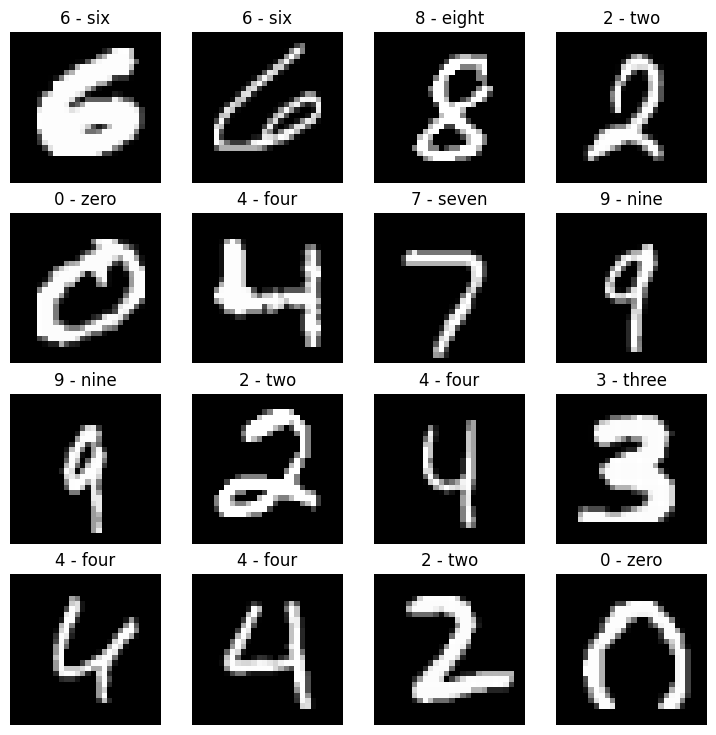

In [7]:
torch.manual_seed(42)
class_names = train_data.classes
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

## 5. Перетворіть навчальні та тестові набори даних MNIST у data loaders за допомогою `torch.utils.data.DataLoader`, встановіть `batch_size=32`.
- Покажіть, яку форму даних вертають дата лоадери.

In [8]:
BATCH_SIZE = 32

train_dataloader = DataLoader(train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Довжина навчального dataloader: {len(train_dataloader)} партій по {BATCH_SIZE}")
print(f"Довжина тестового dataloader: {len(test_dataloader)} партій по {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7998cfa36b70>, <torch.utils.data.dataloader.DataLoader object at 0x7998d87d4380>)
Довжина навчального dataloader: 1875 партій по 32
Довжина тестового dataloader: 313 партій по 32


In [9]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))

print("Форма зображень:", train_features_batch.shape)
print("Форма міток:", train_labels_batch.shape)

Форма зображень: torch.Size([32, 1, 28, 28])
Форма міток: torch.Size([32])


## 6. Відтворіть `ModelV2`, яку ми розглядали на лекції
Це до слова та сама модель з [сайту CNN Explainer](https://poloclub.github.io/cnn-explainer/), також відома як TinyVGG і вона здатна навчатися на наборі даних MNIST.

Напишіть клас моделі.

In [10]:
device = "cpu"

In [11]:
class ModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

In [12]:
torch.manual_seed(42)
model_2_CPU = ModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model_2_CPU


ModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [13]:
from helper_functions import accuracy_fn, print_train_time
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2_CPU.parameters(),
                             lr=0.1)

## 7. Навчіть модель, яку ви побудували в попередній вправі, протягом 5 епох на CPU та GPU і подивіться, скільки часу це займе в кожному з варіантів.

In [14]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1))

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            test_pred = model(X)

            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1)
            )

        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")


In [15]:
torch.manual_seed(42)

train_time_start_model_2 = timer()

epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"Епоха: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_2_CPU,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model_2_CPU,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2_CPU = timer()
total_train_time_model_2_CPU = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2_CPU,
                                           device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Епоха: 0
---------
Train loss: 0.32017 | Train accuracy: 89.23%
Test loss: 0.07544 | Test accuracy: 97.72%

Епоха: 1
---------
Train loss: 0.08204 | Train accuracy: 97.48%
Test loss: 0.06162 | Test accuracy: 97.92%

Епоха: 2
---------
Train loss: 0.06394 | Train accuracy: 98.02%
Test loss: 0.05525 | Test accuracy: 98.10%

Епоха: 3
---------
Train loss: 0.05469 | Train accuracy: 98.27%
Test loss: 0.04741 | Test accuracy: 98.38%

Епоха: 4
---------
Train loss: 0.04825 | Train accuracy: 98.47%
Test loss: 0.04637 | Test accuracy: 98.35%


Train time on cpu: 186.061 seconds


In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [17]:
torch.manual_seed(42)

model_2_GPU = ModelV2(
    input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2_GPU.parameters(), lr=0.1)


train_time_start_GPU = timer()

epochs = 5

for epoch in tqdm(range(epochs)):
    print(f"Епоха: {epoch}\n---------")

    train_step(
        model=model_2_GPU,
        data_loader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )

    test_step(
        model=model_2_GPU,
        data_loader=test_dataloader,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_GPU = timer()

total_train_time_cpu = print_train_time(
    start=train_time_start_GPU,
    end=train_time_end_GPU,
    device=device
)

  0%|          | 0/5 [00:00<?, ?it/s]

Епоха: 0
---------
Train loss: 0.26582 | Train accuracy: 91.22%
Test loss: 0.07203 | Test accuracy: 97.69%

Епоха: 1
---------
Train loss: 0.06807 | Train accuracy: 97.89%
Test loss: 0.04186 | Test accuracy: 98.61%

Епоха: 2
---------
Train loss: 0.05389 | Train accuracy: 98.33%
Test loss: 0.04631 | Test accuracy: 98.47%

Епоха: 3
---------
Train loss: 0.04503 | Train accuracy: 98.52%
Test loss: 0.04456 | Test accuracy: 98.41%

Епоха: 4
---------
Train loss: 0.03995 | Train accuracy: 98.75%
Test loss: 0.03669 | Test accuracy: 98.75%


Train time on cuda: 62.418 seconds


## 8. Зробіть прогнози за допомогою вашої навченої моделі та візуалізуйте принаймні 5 з них, порівнюючи прогноз з цільовою міткою.

In [18]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device):
    """Повертає словник, що містить результати прогнозування моделі на data_loader.

    Args:
        model (torch.nn.Module): Модель PyTorch, здатна робити прогнози на data_loader.
        data_loader (torch.utils.data.DataLoader): Цільовий набір даних для прогнозування.
        loss_fn (torch.nn.Module): Функція втрат моделі.
        accuracy_fn: Функція точності для порівняння прогнозів моделі з істинними мітками.
        device (torch.device): Пристрій для використання для оцінки (наприклад, "cuda" або "cpu").

    Returns:
        (dict): Результати прогнозування моделі на data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    model.to(device)
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            y_pred = model(X)

            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y,
                                y_pred=y_pred.argmax(dim=1))


        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}

In [19]:
model_2_results = eval_model(
    model=model_2_GPU,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=model_2_GPU.parameters().__next__().device # Pass the actual device of model_2
)
model_2_results

{'model_name': 'ModelV2',
 'model_loss': 0.0366920568048954,
 'model_acc': 98.75199680511182}

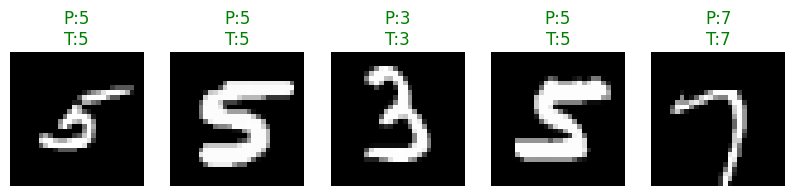

In [20]:
torch.manual_seed(42)

fig = plt.figure(figsize=(10, 5))

for i in range(5):
    random_idx = torch.randint(0, len(test_data), (1,)).item()

    img, label = test_data[random_idx]

    with torch.inference_mode():
        pred = model_2_GPU(
            img.unsqueeze(0).to(device)
        )
        pred_label = pred.argmax(dim=1).item()

    plt.subplot(1, 5, i + 1)
    plt.imshow(img.squeeze(), cmap="gray")

    plt.title(
        f"P:{pred_label}\nT:{label}",
        color="green" if pred_label == label else "red"
    )

    plt.axis(False)

plt.show()

## 9. Побудуйте матрицю плутанини, порівнюючи передбачення вашої моделі з істинними мітками.

In [21]:
y_preds = []
model_2_GPU.eval()
with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        y_pred = model_2_GPU(X)
        y_preds.append(y_pred.argmax(dim=1).cpu())
y_preds = torch.cat(y_preds)

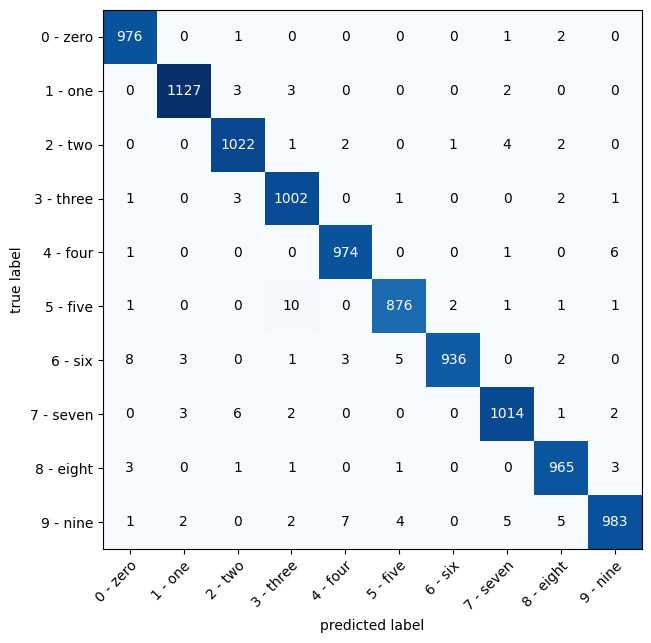

In [22]:
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_preds,
                         target=test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
);

## 10. Виведіть принаймні 9 прикладів, де модель помиляється, разом з тим, якою мала бути мітка зображення.
* Після візуалізації цих прогнозів, як ви думаєте, це більше помилка моделювання чи помилка даних?
* Тобто, чи може модель працювати краще, чи мітки даних занадто близькі одна до одної, що навіть людина не може чітко розрізнити що це за цифра?

In [23]:
wrong_preds = []

model_2_GPU.eval()

with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)

        logits = model_2_GPU(X)
        preds = torch.argmax(logits, dim=1)


        incorrect_mask = preds != y

        for img, pred, target in zip(
            X[incorrect_mask],
            preds[incorrect_mask],
            y[incorrect_mask]
        ):
            wrong_preds.append(
                (img.cpu(), pred.cpu(), target.cpu())
            )

In [24]:
print(f"Кількість помилок: {len(wrong_preds)}")

Кількість помилок: 125


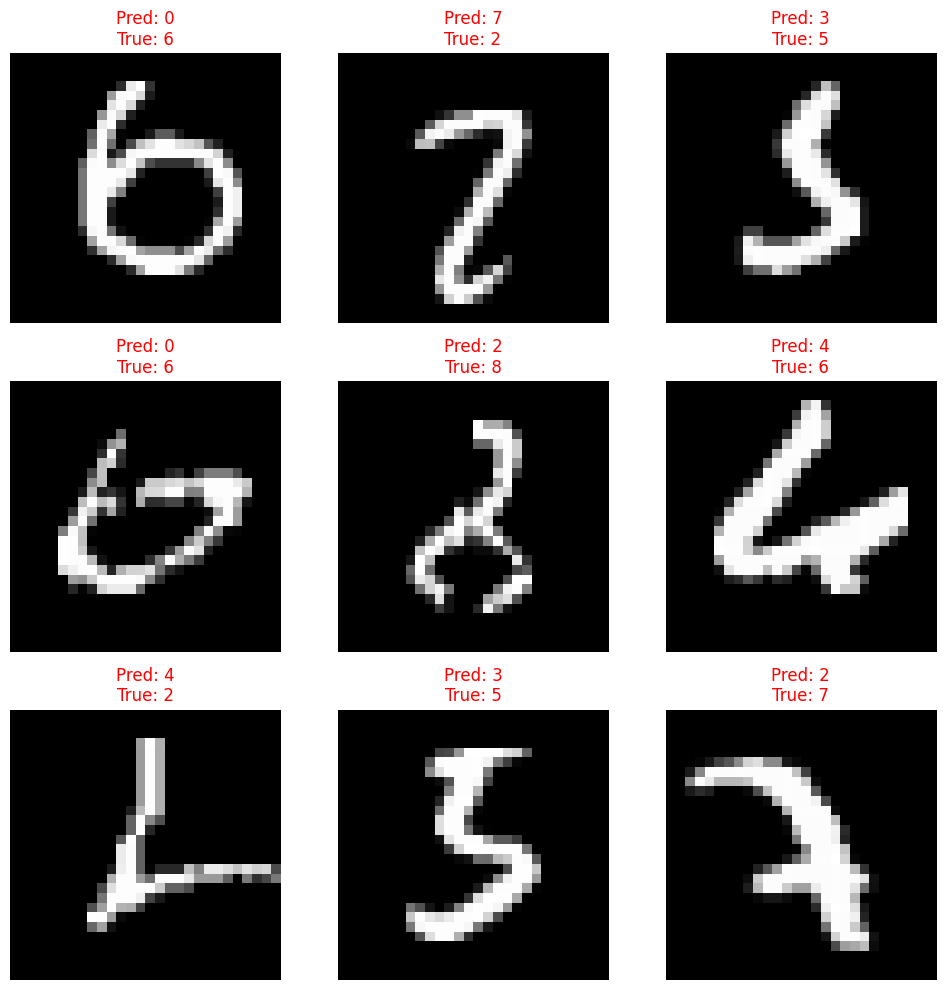

In [25]:
fig = plt.figure(figsize=(10, 10))

for i in range(9):
    img, pred, target = wrong_preds[i]

    fig.add_subplot(3, 3, i + 1)

    plt.imshow(img.squeeze(), cmap="gray")

    plt.title(
        f"Pred: {pred.item()}\nTrue: {target.item()}",
        color="red"
    )

    plt.axis(False)

plt.tight_layout()
plt.show()

Ні, навряд чи модель може працювати значно краще, оскільки деякі зображення цифр є неоднозначними навіть для людини. Частина цифр написана настільки нечітко або схожа на інші класи, що їх складно правильно розпізнати. У деяких випадках я б сама класифікувала цифру так само, як це зробила модель, а не відповідно до її справжньої мітки. Це свідчить про те, що проблема може бути пов'язана не лише з якістю моделі, а й з неоднозначністю або неточністю самих даних та міток.

## 11. Створіть випадковий тензор форми `[1, 3, 64, 64]` і пропустіть його через шар `nn.Conv2d()` з різними налаштуваннями гіперпараметрів (ви можете вибрати будь-які налаштування), що ви помічаєте, якщо параметр `kernel_size` збільшується або зменшується?

In [26]:
torch.manual_seed(42)

images = torch.randn(size=(1, 3, 64, 64))

conv_layer_3 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3,
    stride=1,
    padding=0
)

conv_layer_5 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=5,
    stride=1,
    padding=0
)

conv_layer_7 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=7,
    stride=1,
    padding=0
)

print(conv_layer_3(images).shape)
print(conv_layer_5(images).shape)
print(conv_layer_7(images).shape)

torch.Size([1, 10, 62, 62])
torch.Size([1, 10, 60, 60])
torch.Size([1, 10, 58, 58])


Коли kernel_size збільшується, вихідне зображення стає меншим, якщо padding=0.

kernel_size=3 -> 64 - 3 + 1 = 62
kernel_size=5 -> 64 - 5 + 1 = 60
kernel_size=7 -> 64 - 7 + 1 = 58